In [157]:
import pandas as pd
import plotly.express as px
# import folium
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib import rc
import matplotlib.cm as cm
import numpy as np
import ast
import json
from matplotlib.ticker import FuncFormatter
import geopandas as gpd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from collections import Counter
# from kiwipiepy import Kiwi

mpl.rcParams.update(mpl.rcParamsDefault)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
# , fontproperties=font_prop

In [158]:
course = pd.read_csv('C:/Users/syc09/Desktop/codeit/문체부 공모전/munhwa/course_df.csv')
course = course.drop(columns=['Unnamed: 0'])
course.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,당일,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,중,19:46:00,17:22:00,0,0.143,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,당일,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,하,19:45:00,17:21:00,0,0.066,1
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,당일,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,중,19:45:00,17:21:00,0,0.735,1
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,당일,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,중,19:45:00,17:21:00,0,1.500,1
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,당일,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,상,19:46:00,17:22:00,0,0.199,1


In [159]:
infra = pd.read_csv('C:/Users/syc09/Desktop/codeit/문체부 공모전/munhwa/infra_df.csv')
infra = infra.drop(columns=['Unnamed: 0'])
infra.head()

,place_ID,dist_to_1_foods,dist_to_50_foods,dist_to_70_foods,dist_to_100_foods,dist_to_1_stays,dist_to_10_stays,dist_to_20_stays,dist_to_30_stays
0,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41
1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02
2,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66
3,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43
4,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75


In [160]:
infra.describe()

,dist_to_1_foods,dist_to_50_foods,dist_to_70_foods,dist_to_100_foods,dist_to_1_stays,dist_to_10_stays,dist_to_20_stays,dist_to_30_stays
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.771244,4.285550,4.806655,5.392380,2.187740,5.526890,6.909361,7.697500
std,1.104668,2.776379,2.950097,3.106840,1.949865,2.729308,3.404726,3.818347
min,0.010000,0.490000,0.600000,0.678047,0.050000,0.170000,0.240000,0.340000
25%,0.077126,1.850000,1.937955,2.770443,0.810000,3.282922,4.250000,4.500000
50%,0.230000,4.000000,4.430000,5.250000,1.540000,5.200000,6.900000,7.490000
75%,1.120000,6.350000,6.890000,8.010000,3.260000,7.500000,9.440200,10.619319
max,5.800000,10.666168,11.725158,13.453382,8.282411,11.350000,14.440000,15.900000


In [161]:
merge = pd.read_csv('C:/Users/syc09/Desktop/codeit/문체부 공모전/munhwa/merged_df.csv')
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,당일,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,중,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,당일,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,하,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,당일,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,중,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,당일,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,중,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,당일,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,상,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mountain_name                 113 non-null    object 
 1   course_name                   113 non-null    object 
 2   course_id                     113 non-null    object 
 3   start_point_name              113 non-null    object 
 4   start_point_id                113 non-null    object 
 5   start_lat                     113 non-null    float64
 6   start_lon                     113 non-null    float64
 7   end_point_name                113 non-null    object 
 8   end_point_id                  113 non-null    object 
 9   end_lat                       62 non-null     float64
 10  end_lon                       62 non-null     float64
 11  schedule                      113 non-null    object 
 12  distance_km                   113 non-null    float64
 13  durat

In [163]:
merge.schedule.value_counts()

schedule
당일       104
1박 2일      5
1박2일       4
Name: count, dtype: int64

In [164]:
merge.difficulty.value_counts()

difficulty
중     62
하     27
상     21
중상     1
중하     1
최상     1
Name: count, dtype: int64

In [165]:
merge.sunset_summer.value_counts()

sunset_summer
19:49:00    26
19:50:00    20
19:53:00    14
20:28       13
19:52:00     9
19:51        7
19:46:00     6
20:22        6
19:48        6
19:45:00     3
20:23        2
19:48:00     1
Name: count, dtype: int64

In [166]:
merge.sunset_winter.value_counts()

sunset_winter
17:29:00    17
17:23:00    17
17:26:00    12
17:16:00    11
17:53        7
17:31        7
17:22:00     6
17:52        6
17:37        6
17:25:00     6
17:46        5
17:21:00     4
17:17:00     3
18:40:00     2
17:47        2
17:45        1
17:24:00     1
Name: count, dtype: int64

#### 라벨링

In [167]:
schedule_map = {
    '당일': 1,
    '1박2일': 2,
    '1박 2일': 2  # 띄어쓰기 버전도 포함
}
merge['schedule'] = merge['schedule'].map(schedule_map)

difficulty_map = {
    '하': 1,
    '중하' : 2,
    '중': 3,
    '중상' : 4,
    '상': 5,
    '최상' : 6
}
merge['difficulty'] = merge['difficulty'].map(difficulty_map)


In [168]:
merge.head(1)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.99384,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,3,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.7,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [169]:
merge.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays'],
      dtype='object')

#### 클러스터링

In [170]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [171]:
# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 사용할 컬럼
selected_columns_reduced = [
    'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
    'shelter_count', 'dist_to_nearest_parking_km', 'walkable_to_public_transport',
    'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods',
    'start_dist_to_100_foods', 'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'start_dist_to_20_stays', 'start_dist_to_30_stays'
]

# 결측 제거
cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# 정규화 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(cluster_df_reduced)

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_score = silhouette_score(X_scaled, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

           Scaler Algorithm  Silhouette Score
5    RobustScaler       GMM          0.320400
0  StandardScaler    KMeans          0.287714
6    MinMaxScaler    KMeans          0.282652
3    RobustScaler    KMeans          0.277353
2  StandardScaler       GMM          0.259620
8    MinMaxScaler       GMM          0.195859
1  StandardScaler    DBSCAN          0.136485
4    RobustScaler    DBSCAN         -0.162574
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### 정규화 빼고

In [172]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.689613
1   None    DBSCAN         -1.000000
2   None       GMM          0.718570


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### 정규화 X, GMM

In [173]:
# X는 결측 제거된 원본 feature 데이터 (정규화 X)
X = cluster_df_reduced.copy()  # 이건 결측 제거된 데이터프레임이어야 함

# GMM 모델 정의 및 학습
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

# 원본 데이터에 클러스터 라벨 붙이기
clustered_df = cluster_df_reduced.copy()
clustered_df['gmm_cluster'] = gmm_labels

# 결과 확인 (선택)
print(clustered_df['gmm_cluster'].value_counts())


gmm_cluster
0    88
1    13
2    12
Name: count, dtype: int64


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [174]:
import matplotlib.font_manager as fm
import platform

# Windows의 경우 맑은 고딕 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

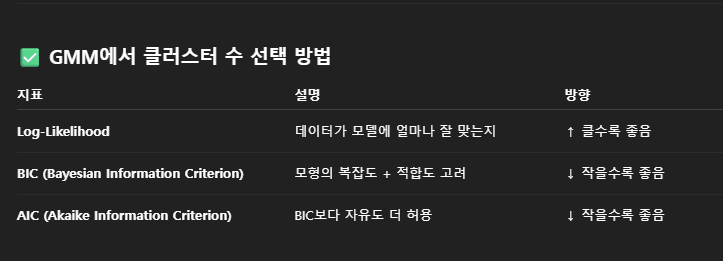

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

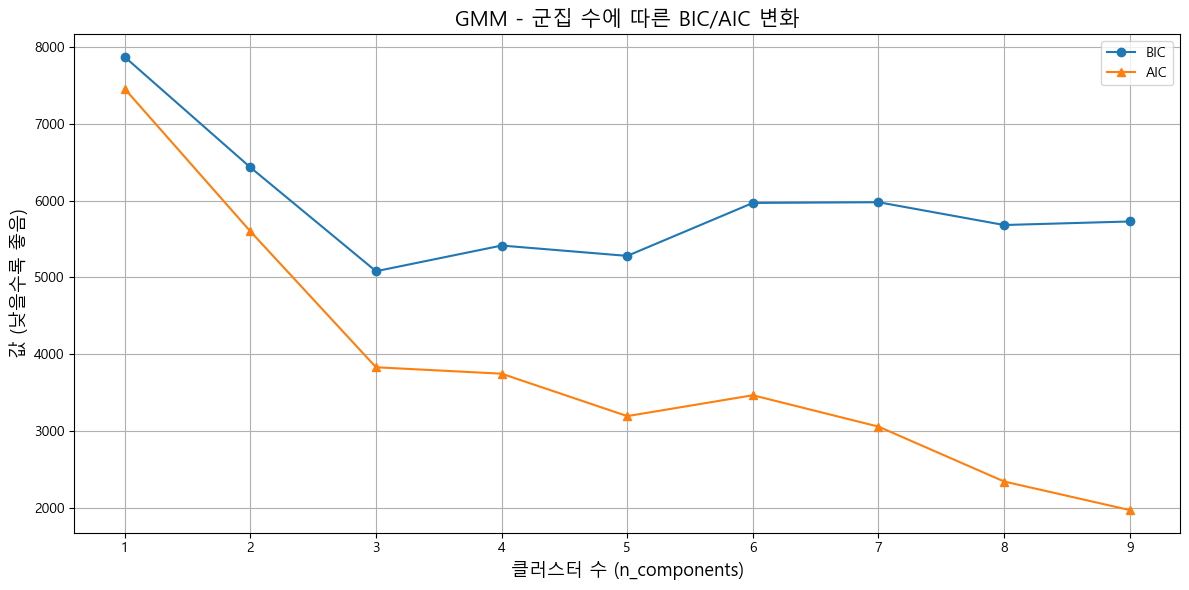

In [175]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import os
os.environ["OMP_NUM_THREADS"] = "1"

X = cluster_df_reduced.copy()  # 결측치 제거된 정규화 없는 feature

n_range = range(1, 10)
bics = []
aics = []
log_likelihoods = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))
    log_likelihoods.append(gmm.score(X) * len(X))  # 전체 로그 가능도

# 📈 시각화
plt.figure(figsize=(12, 6))

plt.plot(n_range, bics, label='BIC', marker='o')
plt.plot(n_range, aics, label='AIC', marker='^')
plt.title('GMM - 군집 수에 따른 BIC/AIC 변화', fontsize=15)
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('값 (낮을수록 좋음)', fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

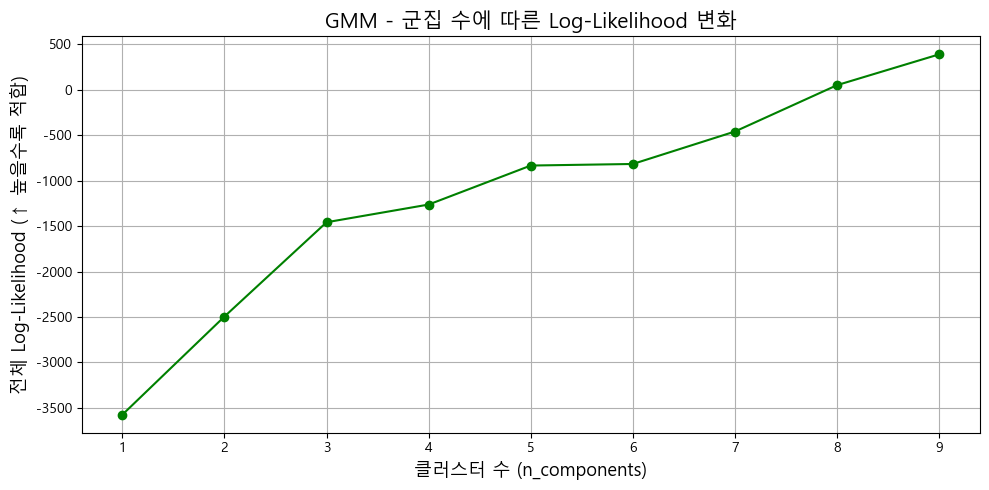

In [176]:
X = cluster_df_reduced.copy()

n_range = range(1, 10)
log_likelihoods = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    # 전체 로그 가능도 = 샘플당 평균 * 샘플 수
    log_likelihood = gmm.score(X) * len(X)
    log_likelihoods.append(log_likelihood)

# 📈 시각화
plt.figure(figsize=(10, 5))
plt.plot(n_range, log_likelihoods, marker='o', color='green')
plt.title('GMM - 군집 수에 따른 Log-Likelihood 변화', fontsize=15)
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('전체 Log-Likelihood (↑ 높을수록 적합)', fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 클러스터 개수는 3으로

In [177]:
# 클러스터링용 데이터
X = cluster_df_reduced.copy()  # 결측치 제거된 상태라고 가정

# GMM 클러스터링 (n_components=3)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

# 클러스터 라벨 추가
clustered_df = X.copy()
clustered_df['cluster'] = gmm_labels

# 클러스터별 평균 특성값 계산
cluster_means = clustered_df.groupby('cluster').mean().round(2)

print(cluster_means)


         schedule  distance_km  duration_min  attraction_count  difficulty  shelter_count  dist_to_nearest_parking_km  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_50_foods  start_dist_to_70_foods  start_dist_to_100_foods  start_dist_to_1_stays  start_dist_to_10_stays  start_dist_to_20_stays  start_dist_to_30_stays
cluster                                                                                                                                                                                                                                                                                                                                           
0            1.00         6.57        207.67              4.43        2.77           0.15                        0.64                          0.82                   0.78                    4.49                    5.03                     5.70                   2.16                    5.32                    6.63        

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [178]:
merge.dist_to_nearest_parking_km.describe()

count    113.000000
mean     115.472319
std      319.980760
min        0.000000
25%        0.133000
50%        0.500000
75%        0.997000
max      999.000000
Name: dist_to_nearest_parking_km, dtype: float64

In [179]:
cluster_means

,schedule,distance_km,duration_min,attraction_count,difficulty,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays
cluster,,,,,,,,,,,,,,,,
0,1.00,6.57,207.67,4.43,2.77,0.15,0.64,0.82,0.78,4.49,5.03,5.70,2.16,5.32,6.63,7.36
1,1.00,5.54,188.08,5.69,2.69,0.15,999.00,0.77,0.66,2.76,2.96,3.37,2.35,4.73,5.72,6.22
2,1.75,17.73,665.83,7.42,4.25,1.50,0.41,0.67,0.71,4.36,5.31,6.19,1.51,5.80,7.30,8.56


#### 주차장 거리 999인 것들 어떻게??

In [180]:
display(len(merge[merge['dist_to_nearest_parking_km'] == 999]))
display(merge[merge['dist_to_nearest_parking_km'] == 999])

13

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
54,북한산,사패산코스,BK_03,송추분소,BK_ENT_02,37.713783,126.982295,사패산입구,BK_EXT_03,NaN,NaN,1,5.5,180,"사패산, 사패코스, 청동좌불",3,1,20:28,17:52,0,999.0,1,BK_ENT_02,0.053542,0.957158,1.392405,2.872733,0.877831,3.282922,4.453115,5.820710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,북한산,오봉코스,BK_04,송추분소,BK_ENT_02,37.713783,126.982295,오봉탐방지원센터,BK_EXT_04,37.712546,126.980721,1,6.5,210,"오봉, 여성봉, 민둥바위, 송추폭포",4,1,20:28,17:52,0,999.0,1,BK_ENT_02,0.053542,0.957158,1.392405,2.872733,0.877831,3.282922,4.453115,5.820710,BK_EXT_04,0.08958,0.901617,1.465255,2.770443,1.016878,3.197107,4.480518,5.970558
59,북한산,백운대코스,BK_08,백운탐방지원센터,BK_ENT_05,37.658401,126.991165,백운대,BK_EXT_01,NaN,NaN,1,1.9,90,"도선사, 산악인 추모비, 백운봉암문, 원효봉, 염초봉, 백운대, 인수봉",8,3,20:28,17:53,1,999.0,1,BK_ENT_05,0.679730,1.880374,1.937955,1.957069,1.689653,3.706180,3.835556,3.856933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,북한산,사모바위코스,BK_09,구기탐방지원센터,BK_ENT_06,37.616367,126.961709,사모바위,BK_EXT_08,NaN,NaN,1,4.8,150,"문수사, 통천문, 사모바위, 비봉, 승가사, 구기동마애석여래좌상, 석조승가대좌상",7,3,20:28,17:53,0,999.0,1,BK_ENT_06,0.075837,1.142954,1.252709,1.358962,2.727068,2.939209,3.460791,3.643529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,북한산,비봉코스,BK_10,비봉탐방지원센터,BK_ENT_07,37.618235,126.953542,비봉,BK_EXT_09,NaN,NaN,1,2.0,60,"목정굴, 금선사, 비봉, 진흥왕순수비유지, 곰바위",5,3,20:28,17:53,0,999.0,1,BK_ENT_07,0.467314,1.413010,1.729073,1.804336,2.133751,2.382157,2.825066,2.998963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,북한산,대동문코스,BK_12,백련공원지킴터,BK_ENT_09,37.645250,127.003851,대동문,BK_EXT_11,NaN,NaN,1,2.7,70,"진달래 능선, 용바위, 대동문, 시단봉, 칼바위, 백련사",6,1,20:28,17:53,0,999.0,1,BK_ENT_09,0.056637,0.542637,0.612713,0.783675,0.698856,2.017941,2.098756,2.119099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,북한산,소귀천코스,BK_13,소귀천공원지킴터,BK_ENT_10,37.652963,126.997243,도선사,BK_EXT_12,NaN,NaN,1,5.1,190,"드라마촬영지(자이언트), 소귀천 계곡, 대동문, 덕장봉, 동장대, 용암문, 김상궁사리탑",7,3,20:28,17:52,1,999.0,1,BK_ENT_10,0.307290,1.259173,1.307694,1.377736,1.358545,2.912827,3.047349,3.066382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,무등산,시무지기폭포 코스,MD_04,증심교,MD_ENT_03,35.132253,126.960929,인계리,MD_EXT_03,35.125812,127.034170,1,12.0,355,"증심교, 새인봉, 토끼등 쉼터, 봉황대, 천제단, 백운암터, 너덜지대, 피안교, 지...",13,3,19:51,17:31,0,999.0,1,MD_ENT_03,0.100000,0.500000,0.700000,1.500000,2.100000,4.000000,4.300000,4.500000,MD_EXT_03,0.60000,4.700000,4.900000,5.700000,1.900000,8.800000,10.700000,10.900000
83,무등산,너릿재 - 옛길코스,MD_05,너릿재 체육쉼터,MD_ENT_04,35.078972,126.957007,원효사,MD_EXT_04,35.148635,126.985756,1,14.5,440,"수레바위산, 너와나목장, 중머리재, 입석대, 서석대, 주검동유적, 제철유적지",7,3,19:51,17:31,0,999.0,0,MD_ENT_04,0.400000,2.900000,3.000000,3.000000,6.100000,7.300000,7.800000,8.100000,MD_EXT_04,0.20000,2.900000,3.100000,3.200000,3.600000,5.500000,6.200000,6.300000
85,무등산,도원마을-규봉 코스,MD_07,도원탐방지원센터,MD_ENT_06,35.114467,127.029330,도원마을,MD_EXT_06,35.120433,127.032759,1,7.5,270,"장불재, 지공너덜, 석불암, 규봉암",4,3,19:51,17:31,0,999.0,0,MD_ENT_06,0.800000,4.900000,5.300000,5.700000,1.200000,9.200000,10.600000,10.800000,MD_EXT_06,0.40000,4.800000,5.100000,6.100000,1.400000,8.700000,10.700000,10.900000


In [181]:
# 네이버지도 기준

merge.loc[merge['start_point_name'] == '송추분소', 'dist_to_nearest_parking_km'] = 0.410 # 북한산국립공원 송추제2주차장
merge.loc[merge['start_point_name'] == '백운탐방지원센터', 'dist_to_nearest_parking_km'] = 0.071 # 도선사광장주차장
merge.loc[merge['start_point_name'] == '구기탐방지원센터', 'dist_to_nearest_parking_km'] = 0.775 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '비봉탐방지원센터', 'dist_to_nearest_parking_km'] = 0.815 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '백련공원지킴터', 'dist_to_nearest_parking_km'] = 0.21   # 아카데미공영주차장
merge.loc[merge['start_point_name'] == '소귀천공원지킴터', 'dist_to_nearest_parking_km'] = 0.128 # 할렐루야기도원 주차장
merge.loc[merge['start_point_name'] == '증심교', 'dist_to_nearest_parking_km'] = 0.526 # 증심사이주단지 공영 주차장 
merge.loc[merge['start_point_name'] == '너릿재 체육쉼터', 'dist_to_nearest_parking_km'] = 3.8 # 너릿재유아숲 공영 주차장
merge.loc[merge['start_point_name'] == '도원탐방지원센터', 'dist_to_nearest_parking_km'] = 0.028 # 도원마을쉼터주차장
merge.loc[merge['start_point_name'] == '장수대분소', 'dist_to_nearest_parking_km'] = 0.365 # 설악산국립공원 한계산성분소 주차장
merge.loc[merge['start_point_name'] == '남설악탐방지원센터', 'dist_to_nearest_parking_km'] = 0.414 # 오색그린야드호텔 공영 주차장
merge.loc[merge['start_point_name'] == '영각탐방지원센터', 'dist_to_nearest_parking_km'] = 1 # 이름이 주차장..?

In [182]:
display(merge[merge['dist_to_nearest_parking_km'] == 999])

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays


#### 다시

In [183]:
# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 사용할 컬럼
selected_columns_reduced = [
    'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
    'shelter_count', 'dist_to_nearest_parking_km', 'walkable_to_public_transport',
    'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods',
    'start_dist_to_100_foods', 'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'start_dist_to_20_stays', 'start_dist_to_30_stays'
]

# 결측 제거
cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# 정규화 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(cluster_df_reduced)

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_score = silhouette_score(X_scaled, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


           Scaler Algorithm  Silhouette Score
6    MinMaxScaler    KMeans          0.311878
0  StandardScaler    KMeans          0.302188
8    MinMaxScaler       GMM          0.290844
2  StandardScaler       GMM          0.274851
5    RobustScaler       GMM          0.237767
3    RobustScaler    KMeans          0.208909
4    RobustScaler    DBSCAN          0.050536
1  StandardScaler    DBSCAN         -0.015424
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [184]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.609692
1   None    DBSCAN         -1.000000
2   None       GMM          0.433054


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

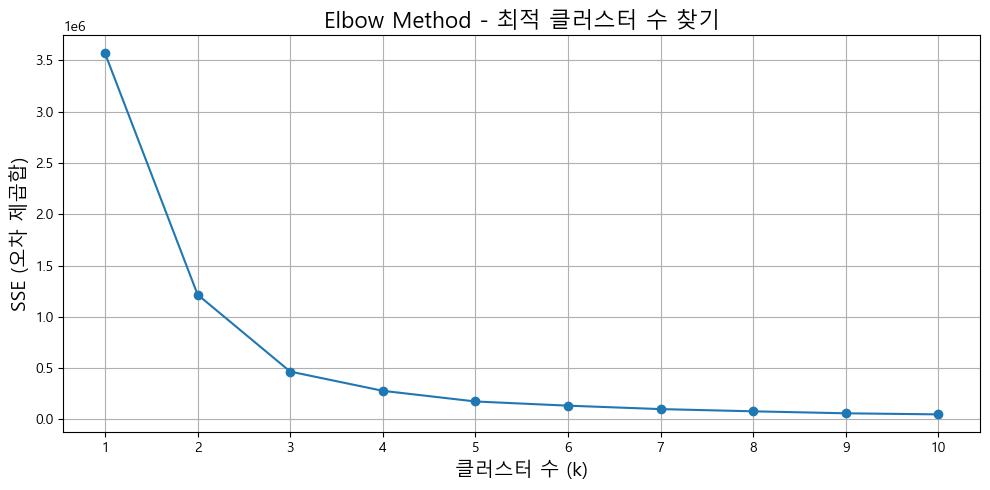

In [185]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 사용할 데이터 (정규화 없이 사용한 것과 동일)
X = cluster_df_reduced.values  # 또는 np.array(cluster_df_reduced)

sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # SSE

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method - 최적 클러스터 수 찾기', fontsize=16)
plt.xlabel('클러스터 수 (k)', fontsize=14)
plt.ylabel('SSE (오차 제곱합)', fontsize=14)
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()


In [186]:
# 세 개 클러스터로 진행

# KMeans 클러스터링
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df_reduced['cluster'] = kmeans_final.fit_predict(cluster_df_reduced)

# 클러스터별 데이터 개수
cluster_counts = cluster_df_reduced['cluster'].value_counts().sort_index()
print("클러스터별 데이터 수:")
print(cluster_counts)

# 클러스터별 평균값
cluster_means = cluster_df_reduced.groupby('cluster').mean()
print("\n클러스터별 평균값:")
print(cluster_means)


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


클러스터별 데이터 수:
cluster
0    40
1    10
2    63
Name: count, dtype: int64

클러스터별 평균값:
         schedule  distance_km  duration_min  attraction_count  difficulty  shelter_count  dist_to_nearest_parking_km  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_50_foods  start_dist_to_70_foods  start_dist_to_100_foods  start_dist_to_1_stays  start_dist_to_10_stays  start_dist_to_20_stays  start_dist_to_30_stays
cluster                                                                                                                                                                                                                                                                                                                                           
0             1.0     9.812500    326.875000          5.475000    3.725000        0.15000                    0.721850                      0.725000               0.751483                5.217088                5.798409                 6.66

In [187]:
len(merge)

113

In [188]:
# 클러스터 결과를 merge에 다시 병합
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = cluster_df_reduced['cluster']

# 각 클러스터에 속한 course_name 목록 보기
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['부인사∼서봉', '동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 1코스 (편도)', '신원사 2코스 (종주)', '수통골 2코스 (종주)', '삼신봉코스', '뱀사골계곡코스', '정령치_바래봉코스', '화엄계곡코스', '피아골코스', '중산리(칼바위)코스', '천왕봉1코스', '천왕봉2코스', '장성봉코스', '칠보산코스', '도명산2코스', '도명산1코스', '신선대2코스', '신선대1코스', '문장대2코스', '대야산코스', '옥녀봉코스', '묘봉코스', '백악산코스', '두로봉코스', '상왕봉코스', '소금강산코스', '계방산1코스', '계방산2코스', '관음사 탐방로', '성판악 탐방로', '늦재 - 옛길 코스', '시무지기폭포 코스', '너릿재 - 옛길코스', '안양산-북산 코스', '도원마을-규봉 코스', '남교리코스', '대청봉코스(오색)', '신풍령코스']

📌 클러스터 1에 속한 코스 목록:
['중산리(장터목)코스', '백무동~중산리코스', '백무동코스', '거림코스', '유평(대원사)코스', '대청봉코스(백담)', '대청봉코스(한계령)', '대청봉코스(설악동)', '공룡능선코스', '종주코스']

📌 클러스터 2에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '치산지∼동봉', '신일지∼은해봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '수통골 1코스 (편도)', '천정코스', '구룡계곡코스', '만복대코스', '반야봉코스', '불일폭포코스', '노고단코스', '장각동코스', '문장대1코스', '문장대코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '사모바위코스', '비봉코스', '보국문코스', '대동문코스', '소귀천코스', '동대산코스', '비로봉코스',

In [189]:
# 클러스터 라벨이 병합된 merge 사용
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = cluster_df_reduced['cluster']

# mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name', 'cluster_0', 'cluster_1', 'cluster_2']

print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2
0           계룡산          5          0          4
1           덕유산          1          1         11
2           무등산          5          0          2
3           북한산          0          0         13
4           설악산          2          4          8
5           속리산         13          0          5
6           오대산          5          0          3
7           지리산          6          5          5
8           팔공산          1          0          8
9           한라산          2          0          4


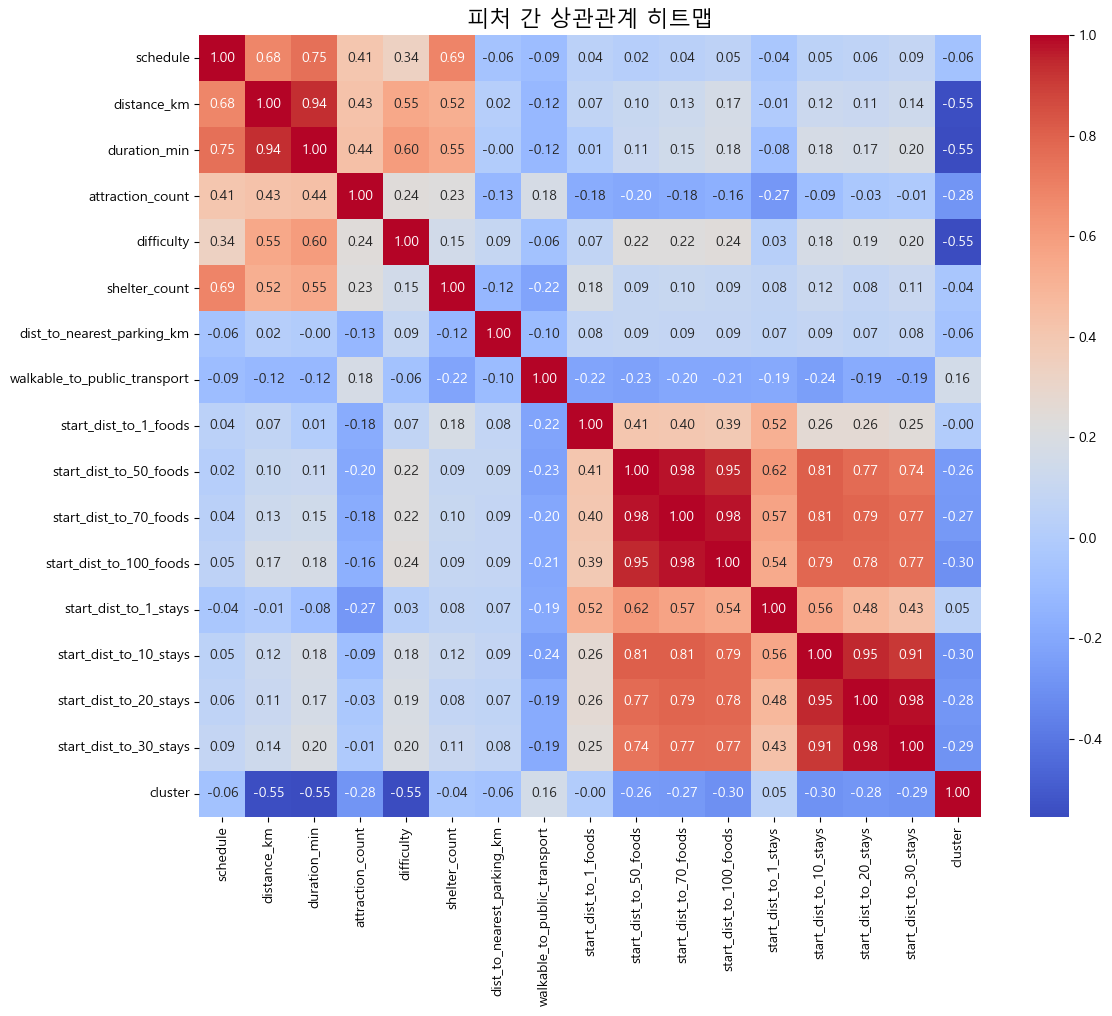

In [190]:
# 상관계수 행렬 계산
corr_matrix = cluster_df_reduced.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("피처 간 상관관계 히트맵", fontsize=16)
plt.tight_layout()
plt.show()

In [191]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = cluster_df_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(cluster_df_reduced.values, i) for i in range(cluster_df_reduced.shape[1])]

print(vif_data)


                         feature         VIF
0                       schedule   58.667088
1                    distance_km   36.217299
2                   duration_min   47.577672
3               attraction_count    7.912922
4                     difficulty   10.336185
5                  shelter_count    2.551403
6     dist_to_nearest_parking_km    1.543293
7   walkable_to_public_transport    5.743918
8          start_dist_to_1_foods    2.359602
9         start_dist_to_50_foods   97.146681
10        start_dist_to_70_foods  199.107438
11       start_dist_to_100_foods  102.245440
12         start_dist_to_1_stays    5.477776
13        start_dist_to_10_stays   67.945986
14        start_dist_to_20_stays  275.478538
15        start_dist_to_30_stays  167.235482
16                       cluster    8.754128


#### 결론

1. 실루엣점수가 제일 높은 게 0.609692. 뭔가 애매..?
2. 엘보우에서는 3개가 적절하다고는 하는데 더 늘려야 유저 입장에서는 선택폭이 넓어지는 거 아닐까??
3. 도착지 기준 음식점, 숙소도 할 건가요??

----------------------------------------------------------

### 0702

1. 주차장까지의 거리 라벨링 (사분위 or 500m / 1km 등)
2. 일출/일몰은 정보 제공용. 포함 안함.

In [192]:
merge.head(1)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.99384,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,3,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.7,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [193]:
merge.dist_to_nearest_parking_km.describe()

count    113.000000
mean       0.622336
std        0.980169
min        0.000000
25%        0.115000
50%        0.410000
75%        0.644000
max        6.600000
Name: dist_to_nearest_parking_km, dtype: float64

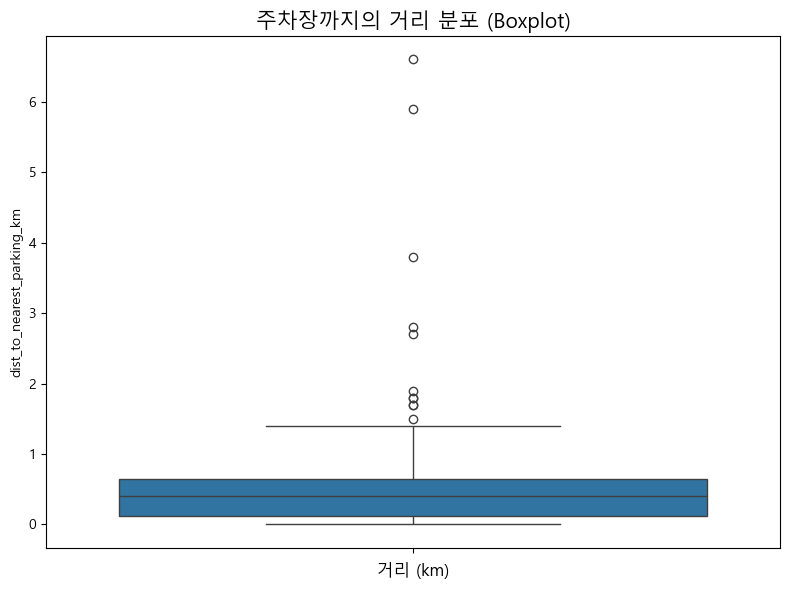

In [194]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=merge['dist_to_nearest_parking_km'])
plt.title('주차장까지의 거리 분포 (Boxplot)', fontsize=15)
plt.xlabel('거리 (km)', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

In [195]:
# 사분위수 기준값 구하기
q1 = merge['dist_to_nearest_parking_km'].quantile(0.25)
q2 = merge['dist_to_nearest_parking_km'].quantile(0.50)
q3 = merge['dist_to_nearest_parking_km'].quantile(0.75)

# 박스플롯 기준 상한 (이상치 기준값)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# 라벨링 함수 정의
def label_parking_dist(x):
    if x > upper_bound:
        return 4  # 이상치
    elif x <= q1:
        return 0
    elif x <= q2:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

# 적용
merge['parking_dist_label'] = merge['dist_to_nearest_parking_km'].apply(label_parking_dist)
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,3,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,3,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,3,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,5,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [196]:
merge.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays', 'parking_dist_label'],
      dtype='object')

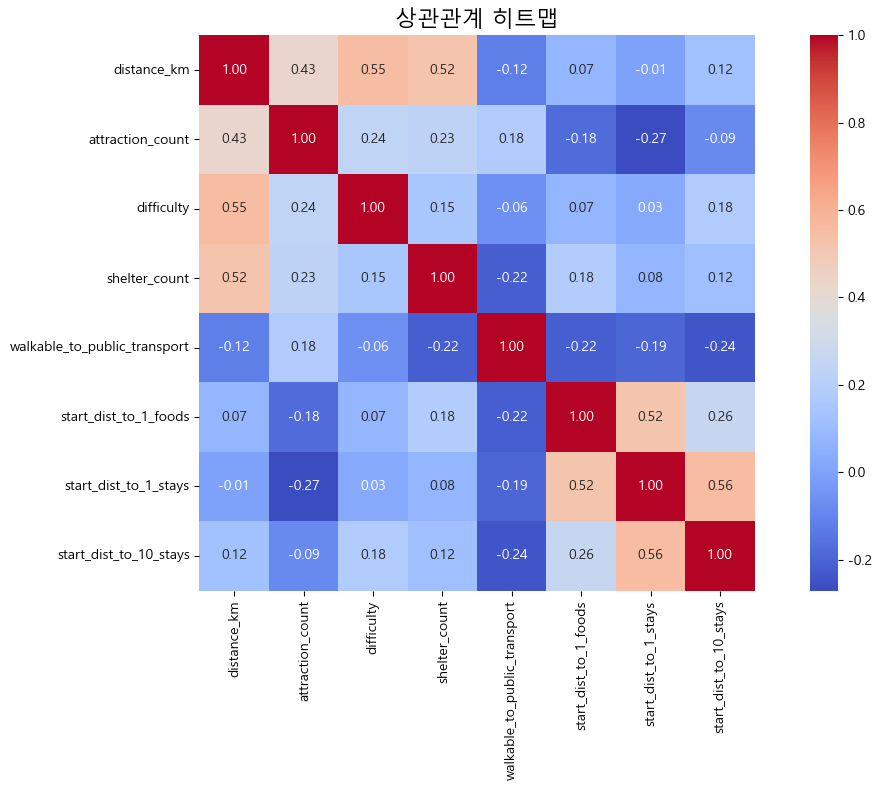

In [197]:
# 분석할 컬럼 리스트
cols = [
    'distance_km',
    'attraction_count', 'difficulty',
    'shelter_count', 
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays',
    'start_dist_to_10_stays']

# 해당 컬럼만 추출
corr_df = merge[cols]

# 상관계수 계산
corr_matrix = corr_df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("상관관계 히트맵", fontsize=16)
plt.tight_layout()
plt.show()

In [198]:
# 상관관계 확인할 컬럼만 추출 (결측 제거)

cols = ['distance_km',
    'attraction_count', 'difficulty',
    'shelter_count', 
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays',
    'start_dist_to_10_stays', 'parking_dist_label']

X = merge[cols].dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                        feature       VIF
0                   distance_km  7.752351
1              attraction_count  6.076010
2                    difficulty  8.228705
3                 shelter_count  1.880231
4  walkable_to_public_transport  4.314625
5         start_dist_to_1_foods  2.088673
6         start_dist_to_1_stays  4.214755
7        start_dist_to_10_stays  6.437997
8            parking_dist_label  2.435566


In [199]:
# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 사용할 컬럼
selected_columns_reduced = cols

# 결측 제거
cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# 정규화 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(cluster_df_reduced)

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_score = silhouette_score(X_scaled, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


           Scaler Algorithm  Silhouette Score
3    RobustScaler    KMeans          0.244993
0  StandardScaler    KMeans          0.242467
2  StandardScaler       GMM          0.235448
6    MinMaxScaler    KMeans          0.229916
1  StandardScaler    DBSCAN          0.219245
4    RobustScaler    DBSCAN          0.200854
5    RobustScaler       GMM          0.196923
8    MinMaxScaler       GMM          0.181406
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [200]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.262413
1   None    DBSCAN         -0.103917
2   None       GMM          0.283512


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [201]:
# 세 개 클러스터로 진행

# KMeans 클러스터링
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df_reduced['cluster'] = kmeans_final.fit_predict(cluster_df_reduced)

# 클러스터별 데이터 개수
cluster_counts = cluster_df_reduced['cluster'].value_counts().sort_index()
print("클러스터별 데이터 수:")
print(cluster_counts)

# 클러스터별 평균값
cluster_means = cluster_df_reduced.groupby('cluster').mean()
print("\n클러스터별 평균값:")
print(cluster_means)


클러스터별 데이터 수:
cluster
0    35
1    32
2    46
Name: count, dtype: int64

클러스터별 평균값:
         distance_km  attraction_count  difficulty  shelter_count  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label
cluster                                                                                                                                                                                  
0           6.365714          3.085714    2.942857       0.228571                      0.714286               1.303218               3.637304                7.597668            1.714286
1          13.796875          7.343750    3.843750       0.625000                      0.781250               0.719702               1.893107                5.881895            1.406250
2           4.313043          4.565217    2.260870       0.108696                      0.869565               0.375523               1.112730                3.156078        

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

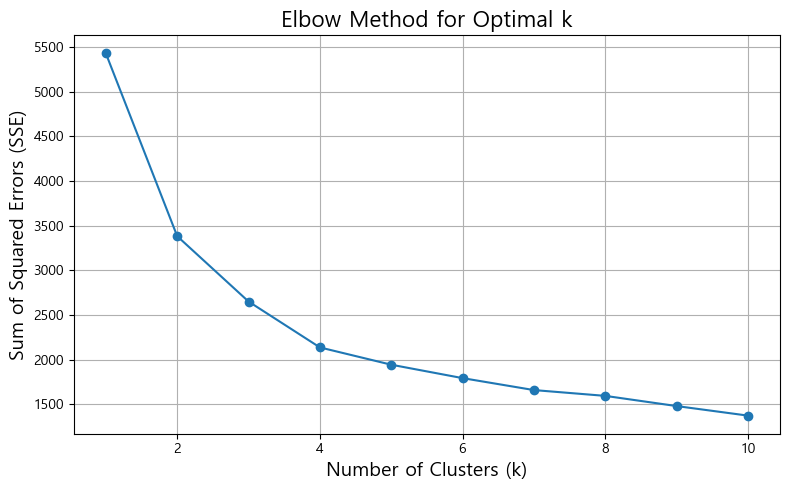

In [202]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 엘보우 메소드용 SSE(오차제곱합) 저장 리스트
sse = []
k_range = range(1, 11)  # k = 1~10까지

# KMeans 반복 수행
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_df_reduced)
    sse.append(kmeans.inertia_)  # inertia_는 SSE 값

# 엘보우 플롯 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


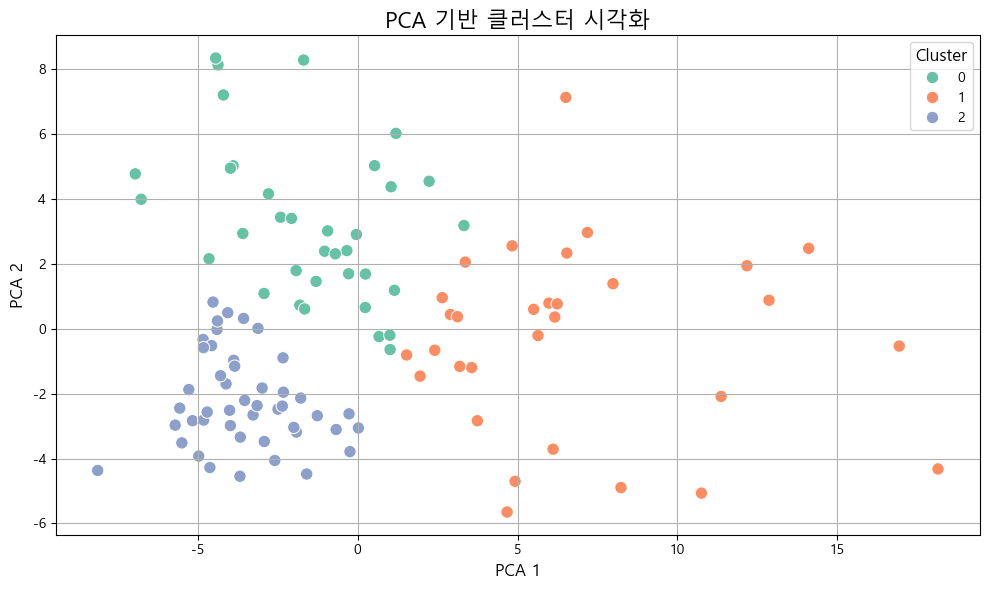

In [203]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 분석에 사용할 컬럼
cols = [
    'distance_km', 'attraction_count', 'difficulty', 'shelter_count',
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays', 'parking_dist_label'
]

# 결측치 제거
X = merge[cols].dropna()

# ✅ 클러스터링 (예: KMeans로 수행했다면 아래처럼)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# 클러스터 라벨을 merge에 반영 (결측치 제거한 인덱스 기준)
merge.loc[X.index, 'cluster'] = cluster_labels

# ✅ PCA 차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ✅ 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', s=80)
plt.title("PCA 기반 클러스터 시각화", fontsize=16)
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.legend(title="Cluster", fontsize=10, title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()



In [204]:
# 1. merge 복사본 생성
merge_with_cluster = merge.copy()

# 2. cluster_df_reduced의 KMeans 클러스터 결과를 merge_with_cluster에 저장
merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_df_reduced['cluster']

# 3. 각 클러스터에 속한 course_name 목록 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['치산지∼동봉', '신일지∼은해봉', '부인사∼서봉', '수통골 2코스 (종주)', '삼신봉코스', '만복대코스', '피아골코스', '반야봉코스', '칠보산코스', '장각동코스', '문장대1코스', '대야산코스', '옥녀봉코스', '묘봉코스', '백악산코스', '두로봉코스', '동대산코스', '비로봉코스', '선재길코스', '계방산1코스', '계방산2코스', '관음사 탐방로', '성판악 탐방로', '영실 탐방로', '어리목 탐방로', '돈내코 탐방로', '어승생악 탐방로', '도원마을-규봉 코스', '백담사코스', '대승폭포코스', '남덕유산코스', '삿갓재코스', '월성재코스', '동엽령코스', '횡경재코스']

📌 클러스터 1에 속한 코스 목록:
['동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 2코스 (종주)', '뱀사골계곡코스', '정령치_바래봉코스', '중산리(장터목)코스', '중산리(칼바위)코스', '백무동~중산리코스', '백무동코스', '거림코스', '유평(대원사)코스', '천왕봉1코스', '천왕봉2코스', '장성봉코스', '도명산2코스', '도명산1코스', '신선대2코스', '신선대1코스', '문장대2코스', '상왕봉코스', '소금강산코스', '늦재 - 옛길 코스', '시무지기폭포 코스', '너릿재 - 옛길코스', '안양산-북산 코스', '수렴동코스', '남교리코스', '대청봉코스(백담)', '대청봉코스(한계령)', '대청봉코스(설악동)', '공룡능선코스', '종주코스']

📌 클러스터 2에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '천정코스', '구룡계곡코스', '화엄계곡코스', '불일폭포코스', '노고단코스', '문장대코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스'

In [205]:
# 1. merge 복사본 생성
merge_with_cluster = merge.copy()

# 2. cluster_df_reduced의 KMeans 클러스터 결과를 merge_with_cluster에 저장
merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_df_reduced['cluster']

# 3. mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 4. 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

# 5. 출력
print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2
0           계룡산          1          3          5
1           덕유산          5          1          7
2           무등산          1          4          2
3           북한산          0          0         13
4           설악산          2          6          6
5           속리산          7          8          3
6           오대산          6          2          0
7           지리산          4          8          4
8           팔공산          3          0          6
9           한라산          6          0          0


In [213]:
from sklearn.mixture import GaussianMixture

# GMM 클러스터링
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
gmm_labels = gmm.predict(X)

# 클러스터 라벨 저장
merge.loc[X.index, 'gmm_cluster'] = gmm_labels

# GMM 클러스터별 평균값
gmm_cluster_means = merge.groupby('gmm_cluster')[cols].mean()
print("\nGMM 클러스터별 평균값:")
print(gmm_cluster_means)

# 클러스터별 데이터 수
gmm_cluster_counts = merge['gmm_cluster'].value_counts().sort_index()
print("\nGMM 클러스터별 데이터 수:")
print(gmm_cluster_counts)

# AIC, BIC 출력
print(f"\nAIC: {gmm.aic(X):,.0f}")
print(f"BIC: {gmm.bic(X):,.0f}")



GMM 클러스터별 평균값:
             distance_km  attraction_count  difficulty  shelter_count  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label
gmm_cluster                                                                                                                                                                                  
0.0            20.212500          8.125000    4.875000       1.500000                      0.750000               1.041250               1.996250                4.428750            1.750000
1.0             4.740000          4.042857    2.485714       0.114286                      0.828571               0.585847               2.114757                4.620623            1.742857
2.0            10.548571          5.857143    3.342857       0.371429                      0.742857               1.045082               2.144790                6.869857            1.142857

GMM 클러스터별 데이터 수:
gmm_cluster
0.0 

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

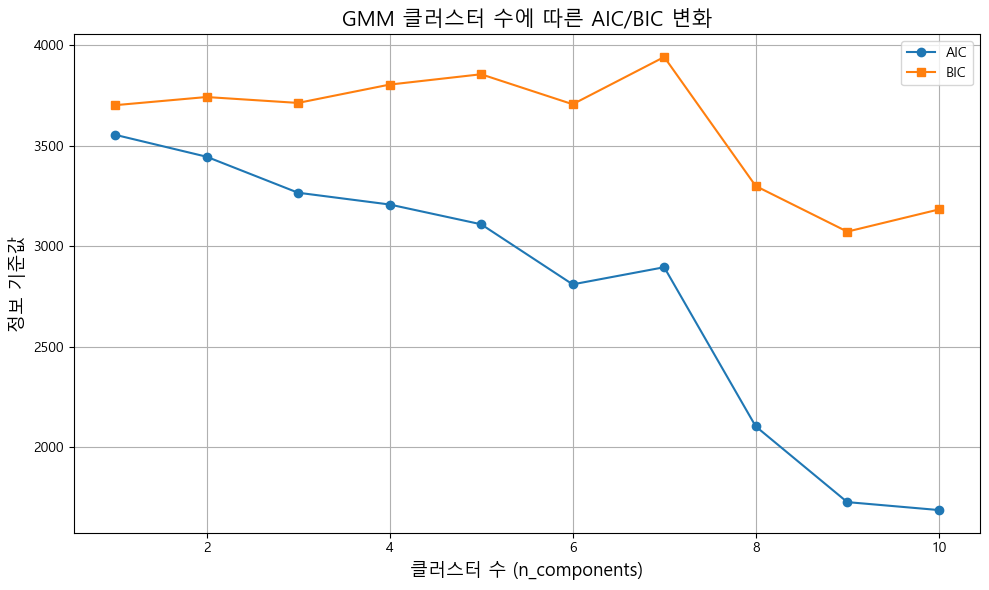

In [214]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 클러스터 수 범위
n_components_range = range(1, 11)

# AIC와 BIC 저장 리스트
aic_values = []
bic_values = []

# 각 클러스터 수에 대해 GMM 적합 후 AIC/BIC 계산
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)  # X는 정규화 또는 스케일링된 feature 데이터
    aic_values.append(gmm.aic(X))
    bic_values.append(gmm.bic(X))

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, aic_values, marker='o', label='AIC')
plt.plot(n_components_range, bic_values, marker='s', label='BIC')
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('정보 기준값', fontsize=13)
plt.title('GMM 클러스터 수에 따른 AIC/BIC 변화', fontsize=15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [216]:
from sklearn.mixture import GaussianMixture

# GMM 클러스터링
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X)
gmm_labels = gmm.predict(X)

# 클러스터 라벨 저장
merge.loc[X.index, 'gmm_cluster'] = gmm_labels

# GMM 클러스터별 평균값
gmm_cluster_means = merge.groupby('gmm_cluster')[cols].mean()
print("\nGMM 클러스터별 평균값:")
print(gmm_cluster_means)

# 클러스터별 데이터 수
gmm_cluster_counts = merge['gmm_cluster'].value_counts().sort_index()
print("\nGMM 클러스터별 데이터 수:")
print(gmm_cluster_counts)

# AIC, BIC 출력
print(f"\nAIC: {gmm.aic(X):,.0f}")
print(f"BIC: {gmm.bic(X):,.0f}")



GMM 클러스터별 평균값:
             distance_km  attraction_count  difficulty  shelter_count  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label
gmm_cluster                                                                                                                                                                                  
0.0              20.2125          8.125000    4.875000       1.500000                      0.750000               1.041250               1.996250                4.428750            1.750000
1.0               4.5220          4.520000    2.400000       0.080000                      0.940000               0.321282               1.284312                3.517592            1.520000
2.0              11.3640          6.800000    3.680000       0.360000                      0.840000               0.436019               1.641577                6.527226            1.320000
3.0               6.3600          

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


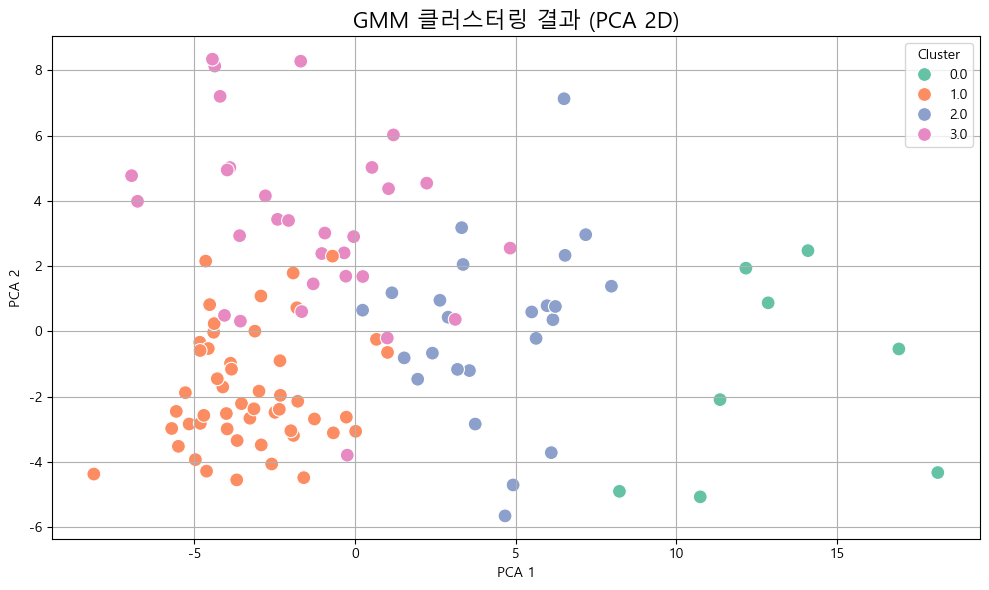

In [217]:
# NaN 제거한 데이터만 사용
X = merge[cols].dropna()
labels = merge.loc[X.index, 'gmm_cluster']

# PCA로 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=100)
plt.title('GMM 클러스터링 결과 (PCA 2D)', fontsize=16)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


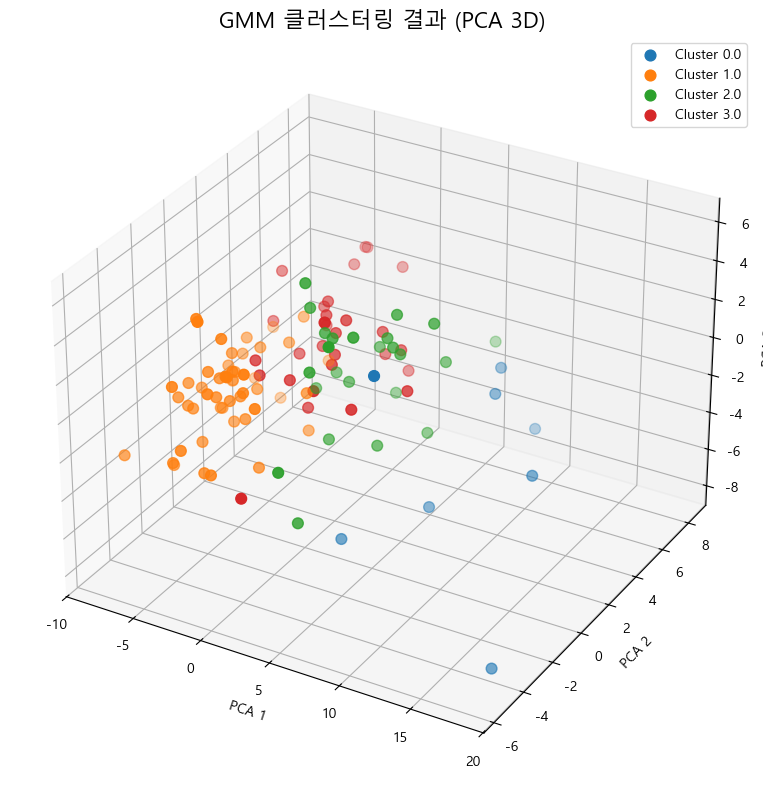

In [218]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 그래프를 위한 모듈
import seaborn as sns

# 결측치 제거한 데이터와 클러스터 라벨
X = merge[cols].dropna()
labels = merge.loc[X.index, 'gmm_cluster']

# PCA로 3차원 축소
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# 3D 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 각 클러스터에 대해 점 찍기
for cluster_id in sorted(labels.unique()):
    idx = labels == cluster_id
    ax.scatter(
        X_pca_3d[idx, 0], X_pca_3d[idx, 1], X_pca_3d[idx, 2],
        label=f'Cluster {cluster_id}', s=60
    )

ax.set_title('GMM 클러스터링 결과 (PCA 3D)', fontsize=16)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.legend()
plt.tight_layout()
plt.show()


In [219]:
# GMM 클러스터 라벨을 merge에 저장한 상태라면 아래처럼 진행
merge_with_cluster = merge.copy()

# GMM 클러스터 라벨을 cluster 컬럼에 복사 (또는 cluster라는 이름으로 새로 지정)
merge_with_cluster['cluster'] = merge_with_cluster['gmm_cluster']

# 각 클러스터에 속한 course_name 목록 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['거림코스', '유평(대원사)코스', '천왕봉1코스', '대청봉코스(백담)', '대청봉코스(한계령)', '대청봉코스(설악동)', '공룡능선코스', '종주코스']

📌 클러스터 1에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '치산지∼동봉', '부인사∼서봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '수통골 2코스 (종주)', '천정코스', '구룡계곡코스', '만복대코스', '화엄계곡코스', '불일폭포코스', '노고단코스', '장각동코스', '문장대1코스', '문장대코스', '묘봉코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '사모바위코스', '비봉코스', '보국문코스', '대동문코스', '소귀천코스', '새인봉 - 입석대 코스', '당산나무 코스', '용소폭포코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '대청봉코스(오색)', '향적봉 1코스', '치목코스', '신풍령코스', '구천동 어사길 코스']

📌 클러스터 2에 속한 코스 목록:
['동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 2코스 (종주)', '삼신봉코스', '뱀사골계곡코스', '중산리(장터목)코스', '중산리(칼바위)코스', '백무동~중산리코스', '백무동코스', '천왕봉2코스', '장성봉코스', '도명산2코스', '도명산1코스', '신선대2코스', '신선대1코스', '문장대2코스', '백악산코스', '상왕봉코스', '소금강산코스', '관음사 탐방로', '늦재 - 옛길 코스', '시무지기폭포 코스', '너릿재 - 옛길코스', '안양산-북산 코스', '남교리코스']

📌 클러스터 3에 속한 코스 목록:
['신일

In [220]:
# GMM 클러스터 라벨을 기반으로 병합
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = merge_with_cluster['gmm_cluster']  # GMM 라벨 사용

# mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2  cluster_3
0           계룡산          0          6          3          0
1           덕유산          1          4          0          8
2           무등산          0          2          4          1
3           북한산          0         13          0          0
4           설악산          4          6          1          3
5           속리산          1          6          8          3
6           오대산          0          0          2          6
7           지리산          2          5          6          3
8           팔공산          0          8          0          1
9           한라산          0          0          1          5
